# Assignment 7: Estimating Neural Beta using a Multilayer Perceptron (MLP)
- This notebook intentionally uses PyTorch throughout.
- Carefully read each TODO and the hints in comments.
- Follow subsequent steps as indicated by the assignment.

In [1]:
# -------------------------
# Standard imports (PyTorch mandated)
# -------------------------
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt

In [2]:
# -------------------------
# Reproducibility + Device
# -------------------------
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Data Processing (including Step 7)

Please implement **all data processing** in this section, including Step 7. The processing should include (but is not limited to):
- Loading the data
- Creating features
- Performing Train/Validation/Test split

In [3]:
import polars as pl

schema = {
    "PERMNO": pl.Int32,    # firm identifier
    "date": pl.Utf8,       
    "SICCD": pl.Int32,     # SIC code
    "RET": pl.Float64,    # returns
    "RETX": pl.Float64,    # return (excluding dividends)
    "vwretd": pl.Float64,   # value-weighted return
    "SHROUT": pl.Int64,
    "PRC": pl.Float64
}

# assume df is your CRSP dataset loaded into Polars
df = pl.read_csv(
    "MSF_1996_2023.csv",
    schema_overrides=schema,
    try_parse_dates=False,
    null_values=["", "NA", "NaN", "B"],  # treat "B" as missing
    ignore_errors=True,
)

# ==== Parse date column ====
df = df.with_columns(
    pl.col("date").str.strptime(pl.Date, format="%m/%d/%Y")
)

# ==== Add year and month columns for convenience ====
df = df.with_columns([
    pl.col("date").dt.year().alias("year"),
    pl.col("date").dt.month().alias("month")
])

expr = (
    pl.when((pl.col("SICCD") >= 1) & (pl.col("SICCD") <= 999)).then(pl.lit("Agriculture"))
    .when((pl.col("SICCD") >= 1000) & (pl.col("SICCD") <= 1499)).then(pl.lit("Mining"))
    .when((pl.col("SICCD") >= 1500) & (pl.col("SICCD") <= 1799)).then(pl.lit("Construction"))
    .when((pl.col("SICCD") >= 2000) & (pl.col("SICCD") <= 3999)).then(pl.lit("Manufacturing"))
    .when((pl.col("SICCD") >= 4000) & (pl.col("SICCD") <= 4999)).then(pl.lit("Transportation"))
    .when((pl.col("SICCD") >= 5000) & (pl.col("SICCD") <= 5199)).then(pl.lit("Wholesale"))
    .when((pl.col("SICCD") >= 5200) & (pl.col("SICCD") <= 5999)).then(pl.lit("Retail"))
    .when((pl.col("SICCD") >= 6000) & (pl.col("SICCD") <= 6799)).then(pl.lit("Finance"))
    .when((pl.col("SICCD") >= 7000) & (pl.col("SICCD") <= 8999)).then(pl.lit("Services"))
    .when((pl.col("SICCD") >= 9000) & (pl.col("SICCD") <= 9999)).then(pl.lit("PublicAdmin"))
    .otherwise(pl.lit("Other"))
    .alias("industry")
)

df = df.with_columns(expr)


# filter years 1996-2023
df = df.with_columns(pl.col("date").dt.year().alias("year"))
df = df.filter((pl.col("year") >= 2005) & (pl.col("year") <= 2023))
df = df.drop_nulls()

expected_months = (2023 - 2005 + 1) * 12  # = 336
min_months = expected_months

firm_counts = (
    df.group_by("PERMNO")
      .agg([
          pl.len().alias("n_obs"),
          pl.first("industry").alias("industry")
      ])
      .filter(pl.col("n_obs") >= min_months)
)

# keep only firms with complete data
df_complete = df.join(firm_counts.select("PERMNO"), on="PERMNO", how="inner")

# Select exactly 10 firms per industry (skip industries with <10 firms)
import random

# Only keep industries with at least 10 firms
industry_counts = (
    firm_counts.group_by("industry")
    .agg(pl.count().alias("n_firms"))
    .filter(pl.col("n_firms") >= 10)
)

valid_industries = industry_counts["industry"].to_list()

sampled_rows = []
for industry in valid_industries:
    group = firm_counts.filter(pl.col("industry") == industry)
    permnos = group["PERMNO"].to_list()
    sampled_permnos = random.sample(permnos, 10)
    for permno in sampled_permnos:
        sampled_rows.append({"industry": industry, "PERMNO": permno})

sampled_firms = pl.DataFrame(sampled_rows).with_columns(pl.col("PERMNO").cast(pl.Int64))

# Ensure PERMNO is Int64 in both dataframes before joining
df_complete = df_complete.with_columns(pl.col("PERMNO").cast(pl.Int64))
sampled_firms = sampled_firms.with_columns(pl.col("PERMNO").cast(pl.Int64))

# Join to get only the data for the sampled firms
df_final = df_complete.join(sampled_firms, on=["PERMNO", "industry"], how="inner")

df = df_final
df = df.with_columns((pl.col("SHROUT") * pl.col("PRC")).alias("mktcap"))
df

C:\Users\jmani\AppData\Local\Temp\ipykernel_29312\3588132154.py:78: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("n_firms"))


PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,mktcap
i64,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,f64
11369,2005-01-31,6020,"""UBSI""","""UNITED BANKSHARES INC""",9213,34.1,27157,-0.10616,43008,-0.10616,-0.026546,2005,1,"""Finance""",1466572.8
11369,2005-02-28,6020,"""UBSI""","""UNITED BANKSHARES INC""",9213,34.08,22334,-0.000586,42868,-0.000586,0.022646,2005,2,"""Finance""",1.4609e6
11369,2005-03-31,6020,"""UBSI""","""UNITED BANKSHARES INC""",9213,33.14,26773,-0.019953,42791,-0.027582,-0.016944,2005,3,"""Finance""",1.4181e6
11369,2005-04-29,6020,"""UBSI""","""UNITED BANKSHARES INC""",9213,30.62,30159,-0.076041,42716,-0.076041,-0.025206,2005,4,"""Finance""",1.3080e6
11369,2005-05-31,6020,"""UBSI""","""UNITED BANKSHARES INC""",9213,33.45,17466,0.092423,42795,0.092423,0.037954,2005,5,"""Finance""",1.4315e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
82694,2023-08-31,1731,"""EME""","""EMCOR GROUP INC""",14268,224.25,72392,0.042829,47135,0.042829,-0.020605,2023,8,"""Construction""",1.0570e7
82694,2023-09-29,1731,"""EME""","""EMCOR GROUP INC""",14268,210.39,54542,-0.061806,47135,-0.061806,-0.04739,2023,9,"""Construction""",9.9167e6
82694,2023-10-31,1731,"""EME""","""EMCOR GROUP INC""",14268,206.64999,63849,-0.016921,47044,-0.017777,-0.028867,2023,10,"""Construction""",9.7216e6


In [4]:
industry_firms = (
    df_final.group_by("industry")
      .agg([
          pl.col("PERMNO").unique().alias("permnos"),
          pl.col("COMNAM").unique().alias("company_names")
      ])
      .sort("industry")
)

for row in industry_firms.iter_rows(named=True):
    industry = row['industry']
    permnos = row['permnos']
    print(f"Industry: {industry}")
    print(f"Companies (PERMNOs): {permnos}\n")

Industry: Construction
Companies (PERMNOs): [19880, 65285, 66245, 70092, 76135, 77661, 79785, 79909, 80415, 82694]

Industry: Finance
Companies (PERMNOs): [11369, 38093, 59459, 72726, 76136, 76266, 76274, 76504, 79019, 82292]

Industry: Manufacturing
Companies (PERMNOs): [19393, 36281, 37402, 41080, 53225, 62958, 65700, 79094, 79702, 79862]

Industry: Mining
Companies (PERMNOs): [18649, 32651, 34833, 39490, 46923, 63765, 75241, 79444, 80204, 80926]

Industry: Retail
Companies (PERMNOs): [11618, 16678, 19502, 76360, 77902, 78900, 79103, 79491, 81665, 81893]

Industry: Services
Companies (PERMNOs): [27633, 51423, 51625, 52230, 72119, 75285, 75510, 75828, 76708, 77917]

Industry: Transportation
Companies (PERMNOs): [11404, 11691, 21928, 23182, 24985, 50789, 67360, 71475, 78981, 80294]

Industry: Wholesale
Companies (PERMNOs): [27684, 47002, 52038, 57913, 61496, 76686, 76927, 81061, 81220, 82515]



In [5]:
df = df.sort(['PERMNO','year','month'])
df = df.drop(['date','TICKER'])
industry_col = df["industry"]  # Save industry column
df = df.to_dummies(columns=["industry"])
df = df.with_columns(industry_col)  # Add original industry column back (if not already)


In [6]:
fama = pl.read_csv("FAMA.csv")
fama = fama.with_columns([
    (pl.col("date") // 100).cast(pl.Int32).alias("year"),
    (pl.col("date") % 100).cast(pl.Int8).alias("month")
])
fama = fama.drop('date')
fama = fama.sort(['year','month'])
fama = fama.filter((pl.col("year") >= 2005) & (pl.col("year") <= 2023))
fama.head()

Mkt-RF,SMB,HML,RF,year,month
f64,f64,f64,f64,i32,i8
-2.75,-1.66,2.06,0.16,2005,1
1.88,-0.57,1.41,0.16,2005,2
-1.94,-1.41,2.07,0.21,2005,3
-2.61,-3.93,0.05,0.21,2005,4
3.65,2.86,-0.58,0.24,2005,5


In [7]:
df_merged = df.join(fama, on=["year", "month"], how="inner")


In [8]:
df_merged.head()

PERMNO,SICCD,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry_Construction,industry_Finance,industry_Manufacturing,industry_Mining,industry_Retail,industry_Services,industry_Transportation,industry_Wholesale,mktcap,industry,Mkt-RF,SMB,HML,RF
i64,i32,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,u8,u8,u8,u8,u8,u8,u8,u8,f64,str,f64,f64,f64,f64
11369,6020,"""UNITED BANKSHARES INC""",9213,34.1,27157,-0.10616,43008,-0.10616,-0.026546,2005,1,0,1,0,0,0,0,0,0,1466572.8,"""Finance""",-2.75,-1.66,2.06,0.16
11369,6020,"""UNITED BANKSHARES INC""",9213,34.08,22334,-0.000586,42868,-0.000586,0.022646,2005,2,0,1,0,0,0,0,0,0,1.4609e6,"""Finance""",1.88,-0.57,1.41,0.16
11369,6020,"""UNITED BANKSHARES INC""",9213,33.14,26773,-0.019953,42791,-0.027582,-0.016944,2005,3,0,1,0,0,0,0,0,0,1.4181e6,"""Finance""",-1.94,-1.41,2.07,0.21
11369,6020,"""UNITED BANKSHARES INC""",9213,30.62,30159,-0.076041,42716,-0.076041,-0.025206,2005,4,0,1,0,0,0,0,0,0,1.3080e6,"""Finance""",-2.61,-3.93,0.05,0.21
11369,6020,"""UNITED BANKSHARES INC""",9213,33.45,17466,0.092423,42795,0.092423,0.037954,2005,5,0,1,0,0,0,0,0,0,1.4315e6,"""Finance""",3.65,2.86,-0.58,0.24


In [9]:
def build_neuralbeta_arrays(df: pl.DataFrame, lookback: int = 12, fama: bool = False):
    """
    Returns numpy arrays for neural beta training.

    X : np.ndarray, shape = [N, ...]
    r_next : np.ndarray, shape = [N]
    mkt_next : np.ndarray, shape = [N]
    """

    import numpy as np

    # Defensive: ensure needed columns
    needed = {"PERMNO", "year", "month", "RETX", "vwretd"}
    if not needed.issubset(set(df.columns)):
        raise ValueError(f"Missing required columns: {needed - set(df.columns)}")
    # Fix: make sure fama columns are present, and check for name variants
    fama_mapping = {
        'Mkt-RF': None,
        'SMB': None,
        'HML': None,
        'RF': None,
    }
    if fama:
        df_columns_lower = {col.lower(): col for col in df.columns}
        # Try to find matching columns (case-insensitive or via dropped dummies)
        for k in fama_mapping:
            if k in df.columns:
                fama_mapping[k] = k
            elif k.lower() in df_columns_lower:
                fama_mapping[k] = df_columns_lower[k.lower()]
            else:
                # Try underscore version, e.g. Mkt_RF
                alt = k.replace("-", "_")
                if alt in df.columns:
                    fama_mapping[k] = alt
                elif alt.lower() in df_columns_lower:
                    fama_mapping[k] = df_columns_lower[alt.lower()]
        missing_fama = [k for k, v in fama_mapping.items() if v is None]
        if missing_fama:
            raise ValueError(
                f"Could not find Fama-French columns: {missing_fama}\n"
                f"Columns present: {df.columns}"
            )

    # Sort
    df = df.sort(["PERMNO", "year", "month"])

    # Industry columns
    industry_cols = [col for col in df.columns if col.startswith("industry_")]

    X_list = []
    r_next_list = []
    mkt_next_list = []

    for group in df.group_by("PERMNO", maintain_order=True):
        g = group[1]
        g = g.drop_nulls(["RETX", "vwretd"])

        if fama:
            fama_cols_real = [fama_mapping[k] for k in ["Mkt-RF", "SMB", "HML", "RF"]]
            if not all(col in g.columns for col in fama_cols_real):
                continue

        n = g.height
        if n <= lookback:
            continue

        firm_returns = g["RETX"].to_numpy()
        market_returns = g["vwretd"].to_numpy()
        industry_dummies = g.select(industry_cols).to_numpy()
        if fama:
            fama_cols_real = [fama_mapping[k] for k in ["Mkt-RF", "SMB", "HML", "RF"]]
            fama_data = g.select(fama_cols_real).to_numpy()

        for t in range(lookback, n):
            past_firm = firm_returns[t - lookback:t]
            past_mkt = market_returns[t - lookback:t]
            ind_dummy = industry_dummies[t]
            if fama:
                past_fama = fama_data[t - lookback:t].flatten()
                features = np.concatenate([past_firm, past_mkt, past_fama, ind_dummy])
            else:
                features = np.concatenate([past_firm, past_mkt, ind_dummy])
            X_list.append(features)
            r_next_list.append(firm_returns[t])
            mkt_next_list.append(market_returns[t])

    if not X_list:
        raise RuntimeError("No valid samples constructed. Check your data, nulls, and lookback.")

    X = np.stack(X_list).astype(np.float32)
    r_next = np.array(r_next_list, dtype=np.float32)
    mkt_next = np.array(mkt_next_list, dtype=np.float32)

    return X, r_next, mkt_next


### Dataset and DataLoader classes

**Dataset:**  
Defines how to access individual samples. It tells PyTorch how to load one data point (features + labels) and how many total samples exist. You need to implement a custom Dataset class here.

**DataLoader:**  
Wraps the Dataset to efficiently provide data during training -- handles batching, shuffling, and parallel loading. Will be used in Step 1.

In [10]:
class NeuralBetaDataset(Dataset):
    """
    Custom dataset that returns:
      x         -> feature vector at time t (shape [D])
      r_next    -> R_{i,t+1}
      mkt_next  -> MKT_{t+1}
    """
    def __init__(self, X, r_next, mkt_next):
        # TODO: store arrays/tensors (ensure shapes align)
        # Convert inputs to tensors if they aren't already
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.r_next = torch.as_tensor(r_next, dtype=torch.float32)
        self.mkt_next = torch.as_tensor(mkt_next, dtype=torch.float32)

        # Ensure correct shapes
        if self.r_next.ndim == 1:
            self.r_next = self.r_next.unsqueeze(1)
        if self.mkt_next.ndim == 1:
            self.mkt_next = self.mkt_next.unsqueeze(1)

        assert len(self.X) == len(self.r_next) == len(self.mkt_next), \
            "X, r_next, and mkt_next must have the same number of samples"

    def __len__(self):
        # TODO: return number of samples
        return len(self.X)

    def __getitem__(self, idx):
        # TODO: return a dict or tuple with x, r_next, mkt_next
        return {
            "x": self.X[idx],
            "r_next": self.r_next[idx],
            "mkt_next": self.mkt_next[idx]
        }


In [11]:
lookback = 12
X, r_next, mkt_next = build_neuralbeta_arrays(df_merged, lookback)

print("X shape:", X.shape)
print("r_next shape:", r_next.shape)
print("mkt_next shape:", mkt_next.shape)

dataset = NeuralBetaDataset(X, r_next, mkt_next)

X shape: (16165, 32)
r_next shape: (16165,)
mkt_next shape: (16165,)


In [12]:
lookback = 12
X, r_next, mkt_next = build_neuralbeta_arrays(df_merged, lookback, True)

print("X shape:", X.shape)
print("r_next shape:", r_next.shape)
print("mkt_next shape:", mkt_next.shape)

dataset = NeuralBetaDataset(X, r_next, mkt_next)

X shape: (16165, 80)
r_next shape: (16165,)
mkt_next shape: (16165,)


In [13]:
print(X[0],r_next[0],mkt_next[0])

[-1.0616e-01 -5.8600e-04 -2.7582e-02 -7.6041e-02  9.2423e-02  6.4574e-02
  6.1780e-02 -6.3740e-02 -1.2712e-02  4.4349e-02  3.5342e-02 -6.7478e-02
 -2.6546e-02  2.2646e-02 -1.6944e-02 -2.5206e-02  3.7954e-02  1.1529e-02
  4.3357e-02 -5.9580e-03  1.0600e-02 -2.0866e-02  4.0326e-02  3.4580e-03
 -2.7500e+00 -1.6600e+00  2.0600e+00  1.6000e-01  1.8800e+00 -5.7000e-01
  1.4100e+00  1.6000e-01 -1.9400e+00 -1.4100e+00  2.0700e+00  2.1000e-01
 -2.6100e+00 -3.9300e+00  5.0000e-02  2.1000e-01  3.6500e+00  2.8600e+00
 -5.8000e-01  2.4000e-01  5.8000e-01  2.5600e+00  2.8000e+00  2.3000e-01
  3.9200e+00  2.8700e+00 -7.8000e-01  2.4000e-01 -1.2000e+00 -1.0700e+00
  1.3400e+00  3.0000e-01  4.8000e-01 -6.2000e-01  7.8000e-01  2.9000e-01
 -2.0400e+00 -1.3000e+00  4.3000e-01  2.7000e-01  3.6100e+00  1.0500e+00
 -1.1800e+00  3.1000e-01 -2.4000e-01 -4.4000e-01  1.5000e-01  3.2000e-01
  0.0000e+00  1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
  0.0000e+00  0.0000e+00] 0.057605 0.040072


## 2. Neural Beta Estimation

### Step 1

In [14]:
class NeuralBetaMLP(nn.Module):
    """Minimal NN for beta_hat prediction."""
    def __init__(self, in_dim=24, hidden_dim=64, activation="relu"):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden_dim)
        match activation:
            case "relu":
                self.activation = nn.ReLU()
            case "linear":
                self.activation = None
            case "sigmoid":
                self.activation = nn.Sigmoid()
            case "tanh":
                self.activation = nn.Tanh()
            case _:
                raise Exception()
        self.layer2 = nn.Linear(hidden_dim, 1)
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, x, m=None):
        op = self.layer1(x)
        if self.activation:
            op = self.activation(op)
        beta = self.layer2(op)
        return beta

    def neural_beta_rmse(self, beta_hat, mkt_next, r_next):
        r_hat = self.alpha + beta_hat * mkt_next
        r_next = r_next.view_as(r_hat)
        mse = torch.mean((r_next - r_hat) ** 2)
        rmse = torch.sqrt(mse)
        return rmse


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for batch in loader:
        x = batch["x"].to(DEVICE)
        r = batch["r_next"].to(DEVICE)
        m = batch["mkt_next"].to(DEVICE)
        optimizer.zero_grad()
        beta_hat = model(x, m)
        loss = model.neural_beta_rmse(beta_hat, m, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / n_batches
    return avg_loss


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    for batch in loader:
        x = batch["x"].to(DEVICE)
        r = batch["r_next"].to(DEVICE)
        m = batch["mkt_next"].to(DEVICE)
        beta_hat = model(x, m)
        loss = model.neural_beta_rmse(beta_hat, m, r)
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / n_batches
    return avg_loss


def fit(model, train_ds, val_ds, batch_size=256, lr=1e-3, max_epochs=50):
    model.to(DEVICE)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": []}
    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, opt)
        val_loss = evaluate(model, val_loader)
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        print(f"Epoch {epoch:03d} | Train RMSE: {train_loss:.6f} | Val RMSE: {val_loss:.6f}")
    return {"model": model, "history": history}


Linear activation as we can have negative betas

In [15]:
train_df = df_merged.filter((pl.col('year') >= 2005) & (pl.col('year') <= 2012))
val_df   = df_merged.filter((pl.col('year') >= 2013) & (pl.col('year') <= 2017))
test_df  = df_merged.filter((pl.col('year') >= 2018) & (pl.col('year') <= 2023))




In [16]:
def make_datasets(data,lookback,fama=False):

    dataset,r,m = build_neuralbeta_arrays(data,lookback,fama)
    dataset = NeuralBetaDataset(dataset,r,m)
    return dataset
    

In [17]:
train_ds,val_ds = make_datasets(train_df,12),make_datasets(val_df,12)

In [18]:
model = NeuralBetaMLP(2*lookback+8)
result = fit(model, train_ds, val_ds, batch_size=256, lr=1e-3, max_epochs=30)

Epoch 001 | Train RMSE: 0.128040 | Val RMSE: 0.090716
Epoch 002 | Train RMSE: 0.123777 | Val RMSE: 0.089179
Epoch 003 | Train RMSE: 0.119426 | Val RMSE: 0.088151
Epoch 004 | Train RMSE: 0.116135 | Val RMSE: 0.087796
Epoch 005 | Train RMSE: 0.115069 | Val RMSE: 0.087782
Epoch 006 | Train RMSE: 0.114701 | Val RMSE: 0.087755
Epoch 007 | Train RMSE: 0.114657 | Val RMSE: 0.087739
Epoch 008 | Train RMSE: 0.114821 | Val RMSE: 0.087795
Epoch 009 | Train RMSE: 0.113545 | Val RMSE: 0.087694
Epoch 010 | Train RMSE: 0.114400 | Val RMSE: 0.087753
Epoch 011 | Train RMSE: 0.114569 | Val RMSE: 0.087744
Epoch 012 | Train RMSE: 0.112722 | Val RMSE: 0.087734
Epoch 013 | Train RMSE: 0.113713 | Val RMSE: 0.087695
Epoch 014 | Train RMSE: 0.113583 | Val RMSE: 0.087721
Epoch 015 | Train RMSE: 0.113754 | Val RMSE: 0.087736
Epoch 016 | Train RMSE: 0.113409 | Val RMSE: 0.087762
Epoch 017 | Train RMSE: 0.113332 | Val RMSE: 0.087706
Epoch 018 | Train RMSE: 0.113340 | Val RMSE: 0.087737
Epoch 019 | Train RMSE: 0.11

### Step 2

Grid/manual search:
  - Hidden units: e.g., [32, 64, 128]
  - Learning rates: e.g., [1e-2, 1e-3, 3e-4]
  - Activations: ["linear", "sigmoid", "tanh", "relu"]
  - Look-back window w: [12, 24, 36]

In [19]:
done=True
if not done:
    import itertools
    hidden_units_list = [32, 64, 128]
    learning_rates     = [1e-2, 1e-3, 3e-4]
    activations        = ["linear", "sigmoid", "tanh", "relu"]
    lookback_windows   = [12, 24, 36]

    best_val_loss = float('inf')
    best_config   = None
    best_model    = None

    for w, hidden_dim, lr, act in itertools.product(lookback_windows,
                                                    hidden_units_list,
                                                    learning_rates,
                                                    activations):
        # update lookback for this config
        in_dim = w * 2
        train_ds = make_datasets(train_df,w)
        val_ds = make_datasets(val_df,w)
        # instantiate model for this config
        print(in_dim,hidden_dim,lr,act)
        model = NeuralBetaMLP(in_dim=in_dim, hidden_dim=hidden_dim, activation=act)
        print(f"Training config: lookback={w}, hidden_units={hidden_dim}, lr={lr}, activation={act}")
        
        # fit the model
        result = fit(model, train_ds, val_ds,
                    batch_size=256,
                    lr=lr,
                    max_epochs=30)
        
        val_loss = result["history"]["val"][-1]
        print(f" → End val RMSE: {val_loss:.6f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_config   = (w, hidden_dim, lr, act)
            best_model    = result["model"]

    print("Best config:", best_config, "with val RMSE:", best_val_loss)

### Step 3

In [20]:
train_ds = make_datasets(train_df,12)
val_ds = make_datasets(val_df,12)
hidden_dim = 128
lr = 0.0003
activation = "relu"
model = NeuralBetaMLP(32,hidden_dim=hidden_dim,activation=activation)
result = fit(model, train_ds, val_ds,
             batch_size=256,
             lr=lr,
             max_epochs=30)

history = result["history"]  

Epoch 001 | Train RMSE: 0.124823 | Val RMSE: 0.090079
Epoch 002 | Train RMSE: 0.123281 | Val RMSE: 0.089388
Epoch 003 | Train RMSE: 0.121361 | Val RMSE: 0.088831
Epoch 004 | Train RMSE: 0.119611 | Val RMSE: 0.088382
Epoch 005 | Train RMSE: 0.118226 | Val RMSE: 0.088057
Epoch 006 | Train RMSE: 0.117166 | Val RMSE: 0.087831
Epoch 007 | Train RMSE: 0.116053 | Val RMSE: 0.087723
Epoch 008 | Train RMSE: 0.115999 | Val RMSE: 0.087685
Epoch 009 | Train RMSE: 0.115385 | Val RMSE: 0.087684
Epoch 010 | Train RMSE: 0.114969 | Val RMSE: 0.087705
Epoch 011 | Train RMSE: 0.114607 | Val RMSE: 0.087704
Epoch 012 | Train RMSE: 0.114350 | Val RMSE: 0.087728
Epoch 013 | Train RMSE: 0.114571 | Val RMSE: 0.087713
Epoch 014 | Train RMSE: 0.114627 | Val RMSE: 0.087711
Epoch 015 | Train RMSE: 0.114610 | Val RMSE: 0.087728
Epoch 016 | Train RMSE: 0.114068 | Val RMSE: 0.087725
Epoch 017 | Train RMSE: 0.114018 | Val RMSE: 0.087707
Epoch 018 | Train RMSE: 0.112843 | Val RMSE: 0.087706
Epoch 019 | Train RMSE: 0.11

In [21]:
def plot_training(history, title="Training Curves (RMSE)"):

    train_losses = history.get("train", [])
    val_losses = history.get("val", [])

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train RMSE")
    plt.plot(val_losses, label="Validation RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

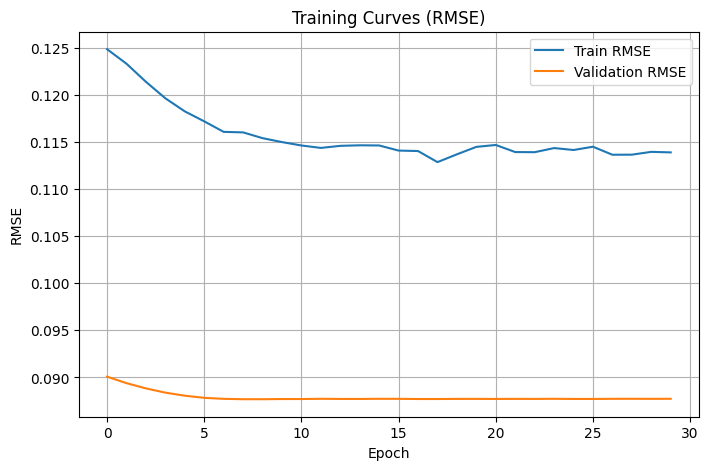

In [22]:
plot_training(history)

### Step 4...

In [23]:
test_ds = make_datasets(test_df,12)

In [24]:
@torch.no_grad()
def inference(model, loader):
    
    model.eval()
    all_beta_hat, all_r_hat, all_r_true = [], [], []

    for batch in loader:
        x = batch["x"].to(DEVICE)
        m = batch["mkt_next"].to(DEVICE)
        r = batch["r_next"].to(DEVICE)

        beta_hat = model(x)
        r_hat = model.alpha + beta_hat * m

        all_beta_hat.append(beta_hat.cpu())
        all_r_hat.append(r_hat.cpu())
        all_r_true.append(r.cpu())

    all_beta_hat = torch.cat(all_beta_hat)
    all_r_hat = torch.cat(all_r_hat)
    all_r_true = torch.cat(all_r_true)

    return all_beta_hat, all_r_hat, all_r_true


In [25]:
beta_pred, r_pred, r_true = inference(model, test_ds)

# compute test RMSE for evaluation
rmse = torch.sqrt(torch.mean((r_pred - r_true) ** 2))
print(f"Test RMSE: {rmse.item():.6f}")

Test RMSE: 0.127966


In [26]:


# make sure your inference outputs are tensors on CPU
from math import nan


beta_pred_np = beta_pred.squeeze().cpu().numpy()
r_pred_np = r_pred.squeeze().cpu().numpy()
r_true_np = r_true.squeeze().cpu().numpy()

# Dynamically set lookback / pad_len based on test_df height and predicted length
lookback = test_df.height - len(beta_pred_np)

# calculate how many nulls to prepend
pad_len = lookback  # usually the same as the window size

# create padded arrays
B_full = np.concatenate([np.full(pad_len, np.nan), beta_pred_np])
R_full = np.concatenate([np.full(pad_len, np.nan), r_pred_np])
R_true_full = np.concatenate([np.full(pad_len, np.nan), r_true_np])

# ensure same length as test_df
assert len(B_full) == test_df.height, f"Length mismatch: {len(B_full)} vs {test_df.height}"

# add to Polars DataFrame
test_df_final = test_df.with_columns([
    pl.Series("B_predicted", B_full),
    pl.Series("R_predicted", R_full),
    pl.Series("R_true", R_true_full),
])


# verify
print(test_df_final.head(15))
print(test_df_final.tail(5))


shape: (15, 29)
┌────────┬───────┬───────────────────────┬────────┬───┬──────┬─────────────┬─────────────┬────────┐
│ PERMNO ┆ SICCD ┆ COMNAM                ┆ PERMCO ┆ … ┆ RF   ┆ B_predicted ┆ R_predicted ┆ R_true │
│ ---    ┆ ---   ┆ ---                   ┆ ---    ┆   ┆ ---  ┆ ---         ┆ ---         ┆ ---    │
│ i64    ┆ i32   ┆ str                   ┆ i64    ┆   ┆ f64  ┆ f64         ┆ f64         ┆ f64    │
╞════════╪═══════╪═══════════════════════╪════════╪═══╪══════╪═════════════╪═════════════╪════════╡
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.11 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.11 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.12 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.14 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.14 ┆ NaN         ┆ NaN    

In [27]:
test_df_final = test_df_final.filter(
    ~(
        pl.col("B_predicted").is_nan() | 
        pl.col("R_predicted").is_nan() |
        pl.col("R_true").is_nan()
    )
)
test_df_final.head()

PERMNO,SICCD,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry_Construction,industry_Finance,industry_Manufacturing,industry_Mining,industry_Retail,industry_Services,industry_Transportation,industry_Wholesale,mktcap,industry,Mkt-RF,SMB,HML,RF,B_predicted,R_predicted,R_true
i64,i32,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,u8,u8,u8,u8,u8,u8,u8,u8,f64,str,f64,f64,f64,f64,f64,f64,f64
27684,5065,"""AVNET INC""",20239,46.76,135368,0.009281,90485,0.009281,0.092057,2023,11,0,0,0,0,0,0,0,1,4231078.6,"""Wholesale""",8.88,-0.1,1.67,0.44,0.788482,0.070785,0.136933
27684,5065,"""AVNET INC""",20239,50.4,93837,0.084474,90485,0.077844,0.053468,2023,12,0,0,0,0,0,0,0,1,4.560444e6,"""Wholesale""",4.85,6.3,4.89,0.43,0.750896,0.025739,0.085383
32651,1041,"""HECLA MINING CO""",20897,3.84,1015862,-0.032746,399019,-0.032746,0.050577,2018,1,0,0,0,1,0,0,0,0,1.5322e6,"""Mining""",5.58,-3.16,-1.32,0.11,0.763557,0.011064,-0.056004
32651,1041,"""HECLA MINING CO""",20897,3.66,946534,-0.046875,399397,-0.046875,-0.039455,2018,2,0,0,0,1,0,0,0,0,1.4618e6,"""Mining""",-3.64,0.27,-1.1,0.11,0.722176,0.028533,0.082781
32651,1041,"""HECLA MINING CO""",20897,3.67,1064281,0.003415,399397,0.002732,-0.018421,2018,3,0,0,0,1,0,0,0,0,1.4658e6,"""Mining""",-2.35,4.05,-0.21,0.12,0.750932,-0.04515,-0.088175


In [28]:
import scipy.stats as stats

stats_by_industry = []

for industry, group_df in test_df_final.group_by("industry", maintain_order=True):
    r_pred = group_df["B_predicted"].to_numpy()
    r_pred = r_pred[~np.isnan(r_pred)]  # drop NaN
    if len(r_pred) == 0:
        continue  # skip empty
    
    stats_dict = {
        "industry": industry,
        "N": len(r_pred),
        "mean": np.mean(r_pred),
        "std": np.std(r_pred, ddof=1),
        "skewness": stats.skew(r_pred, bias=False),
        "kurtosis": stats.kurtosis(r_pred, bias=False, fisher=True),
        "min": np.min(r_pred),
        "max": np.max(r_pred),
        "p1": np.percentile(r_pred, 1),
        "p5": np.percentile(r_pred, 5),
        "p25": np.percentile(r_pred, 25),
        "p50": np.percentile(r_pred, 50),
        "p75": np.percentile(r_pred, 75),
        "p95": np.percentile(r_pred, 95),
        "p99": np.percentile(r_pred, 99),
    }
    stats_by_industry.append(stats_dict)

industry_stats_df = pl.DataFrame(stats_by_industry)


In [29]:
industry_stats_df

industry,N,mean,std,skewness,kurtosis,min,max,p1,p5,p25,p50,p75,p95,p99
list[str],i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Wholesale""]",539,1.095112,0.420927,-0.188588,-0.867554,0.325258,2.211191,0.353044,0.394872,0.751953,1.183233,1.417505,1.672742,1.98222
"[""Mining""]",648,0.843856,0.406803,0.543392,-0.813534,0.290518,1.888128,0.33927,0.368204,0.439523,0.763783,1.181211,1.557364,1.781512
"[""Manufacturing""]",601,0.912185,0.376484,0.219634,-0.944424,0.302713,1.991017,0.329363,0.378956,0.636239,0.83385,1.244743,1.490223,1.76721
"[""Finance""]",648,1.116733,0.307256,-0.15327,-0.683612,0.337485,1.860291,0.429487,0.628293,0.852765,1.153765,1.338915,1.58384,1.750033
"[""Transportation""]",360,1.299882,0.252199,0.081493,1.890404,0.604146,2.574131,0.692101,0.828768,1.158233,1.30194,1.453094,1.662829,1.895398
"[""Services""]",576,1.109506,0.366374,-0.420516,-0.724103,0.303834,1.945117,0.358398,0.417554,0.792427,1.184649,1.377984,1.620332,1.74322
"[""Construction""]",576,1.093772,0.34238,-0.529221,-0.746981,0.314046,1.792969,0.355549,0.419915,0.793908,1.199175,1.348847,1.550284,1.634456
"[""Retail""]",470,0.980413,0.302869,-0.408301,-0.8247,0.320146,1.591853,0.343933,0.421301,0.754117,1.049686,1.227565,1.376956,1.485855


Transport seems to have a high beta, might be due to covid happening in the test period


C:\Users\jmani\AppData\Local\Temp\ipykernel_29312\3653619015.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("N")


shape: (48, 5)
┌──────────────┬──────┬───────────┬──────────┬─────┐
│ industry     ┆ year ┆ beta_mean ┆ beta_std ┆ N   │
│ ---          ┆ ---  ┆ ---       ┆ ---      ┆ --- │
│ str          ┆ i32  ┆ f64       ┆ f64      ┆ u32 │
╞══════════════╪══════╪═══════════╪══════════╪═════╡
│ Construction ┆ 2018 ┆ 1.192019  ┆ 0.27455  ┆ 96  │
│ Construction ┆ 2019 ┆ 1.170936  ┆ 0.308742 ┆ 96  │
│ Construction ┆ 2020 ┆ 1.087962  ┆ 0.385865 ┆ 96  │
│ Construction ┆ 2021 ┆ 0.976739  ┆ 0.345307 ┆ 96  │
│ Construction ┆ 2022 ┆ 1.09235   ┆ 0.361292 ┆ 96  │
│ …            ┆ …    ┆ …         ┆ …        ┆ …   │
│ Wholesale    ┆ 2019 ┆ 0.95967   ┆ 0.417785 ┆ 84  │
│ Wholesale    ┆ 2020 ┆ 1.162607  ┆ 0.429208 ┆ 84  │
│ Wholesale    ┆ 2021 ┆ 1.078082  ┆ 0.466543 ┆ 93  │
│ Wholesale    ┆ 2022 ┆ 1.02965   ┆ 0.419392 ┆ 96  │
│ Wholesale    ┆ 2023 ┆ 1.212286  ┆ 0.285276 ┆ 98  │
└──────────────┴──────┴───────────┴──────────┴─────┘
          industry  year  beta_mean  beta_std    N
0     Construction  2018   1.1920

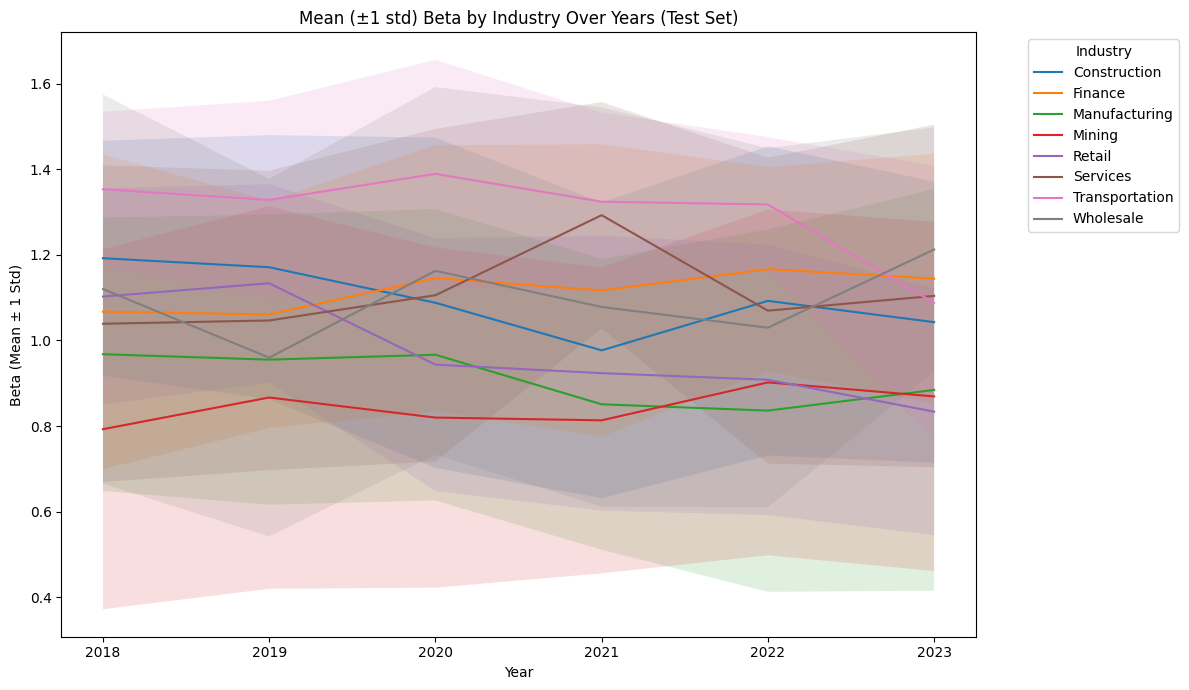

In [30]:

# Compute mean and std of B_predicted for each industry per year
betas_by_year_industry = (
    test_df_final
    .group_by(["industry", "year"])
    .agg([
        pl.col("B_predicted").mean().alias("beta_mean"),
        pl.col("B_predicted").std(ddof=1).alias("beta_std"),
        pl.count().alias("N")
    ])
    .sort(["industry", "year"])
)

# Print the Polars DataFrame
print(betas_by_year_industry)

# Convert to pandas for easier plotting (optional)
betas_pd = betas_by_year_industry.to_pandas()

# Print the pandas DataFrame as well, for convenience
print(betas_pd)

# Choose industries present in the test set
industries = betas_pd["industry"].unique()

plt.figure(figsize=(12,7))
for industry in industries:
    sub = betas_pd[betas_pd["industry"] == industry]
    plt.plot(sub["year"], sub["beta_mean"], label=industry)
    plt.fill_between(
        sub["year"],
        sub["beta_mean"] - sub["beta_std"],
        sub["beta_mean"] + sub["beta_std"],
        alpha=0.15
    )

plt.title("Mean (±1 std) Beta by Industry Over Years (Test Set)")
plt.xlabel("Year")
plt.ylabel("Beta (Mean ± 1 Std)")
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [31]:
train_ds = make_datasets(train_df,12,fama=True)
val_ds = make_datasets(val_df,12,fama=True)
hidden_dim = 128
lr = 0.0003
activation = "relu"
model = NeuralBetaMLP(80,hidden_dim=hidden_dim,activation=activation)
result = fit(model, train_ds, val_ds,
             batch_size=256,
             lr=lr,
             max_epochs=30)

history = result["history"]

Epoch 001 | Train RMSE: 0.133264 | Val RMSE: 0.091731
Epoch 002 | Train RMSE: 0.118550 | Val RMSE: 0.089806
Epoch 003 | Train RMSE: 0.116736 | Val RMSE: 0.089453
Epoch 004 | Train RMSE: 0.116224 | Val RMSE: 0.089281
Epoch 005 | Train RMSE: 0.115834 | Val RMSE: 0.089154
Epoch 006 | Train RMSE: 0.115502 | Val RMSE: 0.089084
Epoch 007 | Train RMSE: 0.115717 | Val RMSE: 0.088993
Epoch 008 | Train RMSE: 0.115021 | Val RMSE: 0.088970
Epoch 009 | Train RMSE: 0.114915 | Val RMSE: 0.088912
Epoch 010 | Train RMSE: 0.115444 | Val RMSE: 0.088853
Epoch 011 | Train RMSE: 0.114300 | Val RMSE: 0.088779
Epoch 012 | Train RMSE: 0.114276 | Val RMSE: 0.088724
Epoch 013 | Train RMSE: 0.114575 | Val RMSE: 0.088679
Epoch 014 | Train RMSE: 0.115073 | Val RMSE: 0.088669
Epoch 015 | Train RMSE: 0.114659 | Val RMSE: 0.088633
Epoch 016 | Train RMSE: 0.113430 | Val RMSE: 0.088575
Epoch 017 | Train RMSE: 0.114295 | Val RMSE: 0.088558
Epoch 018 | Train RMSE: 0.113302 | Val RMSE: 0.088598
Epoch 019 | Train RMSE: 0.11

In [32]:
test_ds_fama = make_datasets(test_df,12,fama=True)


In [33]:
test_ds_fama.X.shape

torch.Size([4418, 80])

In [34]:
beta_pred, r_pred, r_true = inference(model, test_ds_fama)

# compute test RMSE for evaluation
rmse = torch.sqrt(torch.mean((r_pred - r_true) ** 2))
print(f"Test RMSE: {rmse.item():.6f}")

Test RMSE: 0.132302


In [36]:
# make sure your inference outputs are tensors on CPU
from math import nan


beta_pred_np = beta_pred.squeeze().cpu().numpy()
r_pred_np = r_pred.squeeze().cpu().numpy()
r_true_np = r_true.squeeze().cpu().numpy()

# Dynamically set lookback / pad_len based on test_df height and predicted length
lookback = test_df.height - len(beta_pred_np)

# calculate how many nulls to prepend
pad_len = lookback  # usually the same as the window size

# create padded arrays
B_full = np.concatenate([np.full(pad_len, np.nan), beta_pred_np])
R_full = np.concatenate([np.full(pad_len, np.nan), r_pred_np])
R_true_full = np.concatenate([np.full(pad_len, np.nan), r_true_np])

# ensure same length as test_df
assert len(B_full) == test_df.height, f"Length mismatch: {len(B_full)} vs {test_df.height}"

# add to Polars DataFrame, using test_df_final_fama
test_df_final_fama = test_df.with_columns([
    pl.Series("B_predicted", B_full),
    pl.Series("R_predicted", R_full),
    pl.Series("R_true", R_true_full),
])


# verify
print(test_df_final_fama.head(15))
print(test_df_final_fama.tail(5))

shape: (15, 29)
┌────────┬───────┬───────────────────────┬────────┬───┬──────┬─────────────┬─────────────┬────────┐
│ PERMNO ┆ SICCD ┆ COMNAM                ┆ PERMCO ┆ … ┆ RF   ┆ B_predicted ┆ R_predicted ┆ R_true │
│ ---    ┆ ---   ┆ ---                   ┆ ---    ┆   ┆ ---  ┆ ---         ┆ ---         ┆ ---    │
│ i64    ┆ i32   ┆ str                   ┆ i64    ┆   ┆ f64  ┆ f64         ┆ f64         ┆ f64    │
╞════════╪═══════╪═══════════════════════╪════════╪═══╪══════╪═════════════╪═════════════╪════════╡
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.11 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.11 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.12 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.14 ┆ NaN         ┆ NaN         ┆ NaN    │
│ 11369  ┆ 6020  ┆ UNITED BANKSHARES INC ┆ 9213   ┆ … ┆ 0.14 ┆ NaN         ┆ NaN    

In [37]:
test_df_final_fama = test_df_final_fama.filter(
    ~(
        pl.col("B_predicted").is_nan() | 
        pl.col("R_predicted").is_nan() |
        pl.col("R_true").is_nan()
    )
)
test_df_final_fama.head()

PERMNO,SICCD,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry_Construction,industry_Finance,industry_Manufacturing,industry_Mining,industry_Retail,industry_Services,industry_Transportation,industry_Wholesale,mktcap,industry,Mkt-RF,SMB,HML,RF,B_predicted,R_predicted,R_true
i64,i32,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,u8,u8,u8,u8,u8,u8,u8,u8,f64,str,f64,f64,f64,f64,f64,f64,f64
27684,5065,"""AVNET INC""",20239,46.76,135368,0.009281,90485,0.009281,0.092057,2023,11,0,0,0,0,0,0,0,1,4231078.6,"""Wholesale""",8.88,-0.1,1.67,0.44,1.111433,0.101705,0.136933
27684,5065,"""AVNET INC""",20239,50.4,93837,0.084474,90485,0.077844,0.053468,2023,12,0,0,0,0,0,0,0,1,4.560444e6,"""Wholesale""",4.85,6.3,4.89,0.43,0.233392,0.01121,0.085383
32651,1041,"""HECLA MINING CO""",20897,3.84,1015862,-0.032746,399019,-0.032746,0.050577,2018,1,0,0,0,1,0,0,0,0,1.5322e6,"""Mining""",5.58,-3.16,-1.32,0.11,1.43794,0.022211,-0.056004
32651,1041,"""HECLA MINING CO""",20897,3.66,946534,-0.046875,399397,-0.046875,-0.039455,2018,2,0,0,0,1,0,0,0,0,1.4618e6,"""Mining""",-3.64,0.27,-1.1,0.11,1.655343,0.066298,0.082781
32651,1041,"""HECLA MINING CO""",20897,3.67,1064281,0.003415,399397,0.002732,-0.018421,2018,3,0,0,0,1,0,0,0,0,1.4658e6,"""Mining""",-2.35,4.05,-0.21,0.12,0.668705,-0.037672,-0.088175


In [39]:
import scipy.stats as stats

stats_by_industry = []

for industry, group_df in test_df_final_fama.group_by("industry", maintain_order=True):
    r_pred = group_df["B_predicted"].to_numpy()
    r_pred = r_pred[~np.isnan(r_pred)]  # drop NaN
    if len(r_pred) == 0:
        continue  # skip empty
    
    stats_dict = {
        "industry": industry,
        "N": len(r_pred),
        "mean": np.mean(r_pred),
        "std": np.std(r_pred, ddof=1),
        "skewness": stats.skew(r_pred, bias=False),
        "kurtosis": stats.kurtosis(r_pred, bias=False, fisher=True),
        "min": np.min(r_pred),
        "max": np.max(r_pred),
        "p1": np.percentile(r_pred, 1),
        "p5": np.percentile(r_pred, 5),
        "p25": np.percentile(r_pred, 25),
        "p50": np.percentile(r_pred, 50),
        "p75": np.percentile(r_pred, 75),
        "p95": np.percentile(r_pred, 95),
        "p99": np.percentile(r_pred, 99),
    }
    stats_by_industry.append(stats_dict)

industry_stats_df = pl.DataFrame(stats_by_industry)

In [40]:
industry_stats_df

industry,N,mean,std,skewness,kurtosis,min,max,p1,p5,p25,p50,p75,p95,p99
list[str],i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Wholesale""]",539,1.22865,0.660687,-0.04487,-0.404843,-0.49809,2.924196,-0.235446,0.10861,0.77165,1.240447,1.688993,2.270197,2.681908
"[""Mining""]",648,1.095093,0.64265,0.011593,-0.433497,-0.507686,2.709352,-0.282364,0.06297,0.657233,1.098327,1.550002,2.193591,2.551892
"[""Manufacturing""]",601,1.140232,0.653994,0.035632,-0.364389,-0.498475,3.177954,-0.291937,0.059329,0.669147,1.167578,1.574806,2.232565,2.606333
"[""Finance""]",648,1.280723,0.619532,-0.024528,-0.468167,-0.288898,2.740514,-0.030075,0.256032,0.808095,1.299985,1.692246,2.281522,2.673631
"[""Transportation""]",360,1.379983,0.600768,0.035406,-0.460673,-0.017272,2.849382,0.053951,0.43924,0.905839,1.448616,1.727536,2.329523,2.679826
"[""Services""]",576,1.257878,0.636722,-0.031303,-0.428583,-0.514694,2.77501,-0.1004,0.220218,0.775695,1.281681,1.68422,2.289025,2.645939
"[""Construction""]",576,1.260944,0.638737,-0.003242,-0.3766,-0.500262,2.794552,-0.106727,0.204863,0.782075,1.254472,1.675369,2.298972,2.67106
"[""Retail""]",470,1.197543,0.629531,0.01612,-0.38633,-0.502052,2.68206,-0.156159,0.197481,0.716959,1.214759,1.612115,2.249812,2.612489


shape: (48, 5)
┌──────────────┬──────┬───────────┬──────────┬─────┐
│ industry     ┆ year ┆ beta_mean ┆ beta_std ┆ N   │
│ ---          ┆ ---  ┆ ---       ┆ ---      ┆ --- │
│ str          ┆ i32  ┆ f64       ┆ f64      ┆ u32 │
╞══════════════╪══════╪═══════════╪══════════╪═════╡
│ Construction ┆ 2018 ┆ 1.289225  ┆ 0.625943 ┆ 96  │
│ Construction ┆ 2019 ┆ 1.372452  ┆ 0.584619 ┆ 96  │
│ Construction ┆ 2020 ┆ 1.223515  ┆ 0.681649 ┆ 96  │
│ Construction ┆ 2021 ┆ 1.239425  ┆ 0.651413 ┆ 96  │
│ Construction ┆ 2022 ┆ 1.222475  ┆ 0.611106 ┆ 96  │
│ …            ┆ …    ┆ …         ┆ …        ┆ …   │
│ Wholesale    ┆ 2019 ┆ 1.215824  ┆ 0.617873 ┆ 84  │
│ Wholesale    ┆ 2020 ┆ 1.30285   ┆ 0.603233 ┆ 84  │
│ Wholesale    ┆ 2021 ┆ 1.188158  ┆ 0.70961  ┆ 93  │
│ Wholesale    ┆ 2022 ┆ 1.182877  ┆ 0.716006 ┆ 96  │
│ Wholesale    ┆ 2023 ┆ 1.286365  ┆ 0.603796 ┆ 98  │
└──────────────┴──────┴───────────┴──────────┴─────┘
          industry  year  beta_mean  beta_std    N
0     Construction  2018   1.2892

C:\Users\jmani\AppData\Local\Temp\ipykernel_29312\3444540067.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("N")


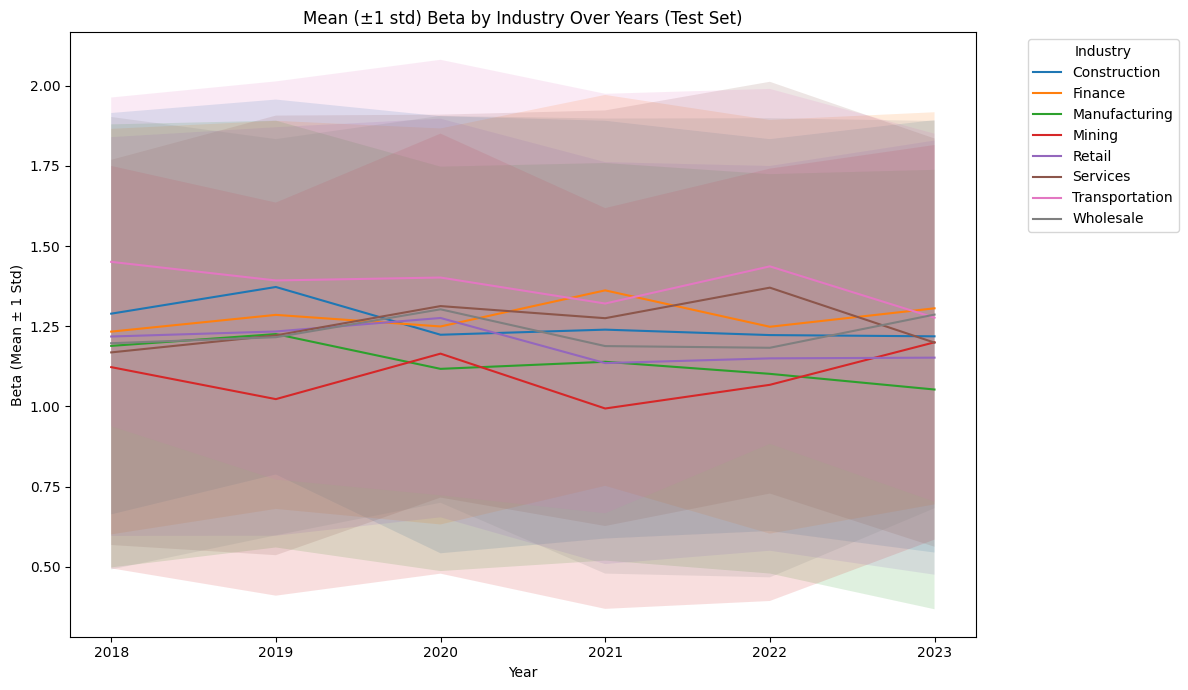

In [41]:
betas_by_year_industry = (
    test_df_final_fama
    .group_by(["industry", "year"])
    .agg([
        pl.col("B_predicted").mean().alias("beta_mean"),
        pl.col("B_predicted").std(ddof=1).alias("beta_std"),
        pl.count().alias("N")
    ])
    .sort(["industry", "year"])
)

# Print the Polars DataFrame
print(betas_by_year_industry)

# Convert to pandas for easier plotting (optional)
betas_pd = betas_by_year_industry.to_pandas()

# Print the pandas DataFrame as well, for convenience
print(betas_pd)

# Choose industries present in the test set
industries = betas_pd["industry"].unique()

plt.figure(figsize=(12,7))
for industry in industries:
    sub = betas_pd[betas_pd["industry"] == industry]
    plt.plot(sub["year"], sub["beta_mean"], label=industry)
    plt.fill_between(
        sub["year"],
        sub["beta_mean"] - sub["beta_std"],
        sub["beta_mean"] + sub["beta_std"],
        alpha=0.15
    )

plt.title("Mean (±1 std) Beta by Industry Over Years (Test Set)")
plt.xlabel("Year")
plt.ylabel("Beta (Mean ± 1 Std)")
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [54]:
test_df_final_fama = test_df_final_fama.drop_nulls()
test_df_final_fama = (
    test_df_final_fama
    .with_columns([
        pl.col("B_predicted")
        .rank("average")
        .alias("beta_rank"),
        pl.len().alias("n_firms"),
    ])
    .with_columns([
        (
            (pl.col("beta_rank") / pl.col("n_firms") * 5)
            .ceil()
            .cast(pl.Int8)
        ).alias("_quintile_raw")
    ])
    .with_columns([
        pl.when(pl.col("_quintile_raw") < 1)
          .then(1)
          .when(pl.col("_quintile_raw") > 5)
          .then(5)
          .otherwise(pl.col("_quintile_raw"))
          .alias("quintile")
    ])
    .drop("_quintile_raw")
)
equal_weight_quintiles = (
    test_df_final_fama
    .group_by("quintile")
    .agg([
        pl.col("B_predicted").mean().alias("mean_beta"),
        pl.col("RETX").mean().alias("ewret"),
        pl.len().alias("n_stocks")
    ])
    .sort("quintile")
)
print(equal_weight_quintiles)


shape: (5, 4)
┌──────────┬───────────┬──────────┬──────────┐
│ quintile ┆ mean_beta ┆ ewret    ┆ n_stocks │
│ ---      ┆ ---       ┆ ---      ┆ ---      │
│ i8       ┆ f64       ┆ f64      ┆ u32      │
╞══════════╪═══════════╪══════════╪══════════╡
│ 1        ┆ 0.314825  ┆ 0.013756 ┆ 883      │
│ 2        ┆ 0.857105  ┆ 0.014243 ┆ 884      │
│ 3        ┆ 1.243133  ┆ 0.020542 ┆ 883      │
│ 4        ┆ 1.577923  ┆ 0.009326 ┆ 884      │
│ 5        ┆ 2.114582  ┆ 0.006308 ┆ 884      │
└──────────┴───────────┴──────────┴──────────┘


In [55]:
value_weight_deciles = (
    test_df_final_fama
    .group_by("quintile")
    .agg([
        pl.col("B_predicted").mean().alias("mean_beta"),
        (
            (pl.col("RETX") * pl.col("mktcap")).sum() / pl.col("mktcap").sum()
        ).alias("vwret"),
        pl.len().alias("n_stocks"),
        pl.col("mktcap").sum().alias("total_mktcap")
    ])
    .sort("quintile")
)

print(value_weight_deciles)


shape: (5, 5)
┌──────────┬───────────┬──────────┬──────────┬──────────────┐
│ quintile ┆ mean_beta ┆ vwret    ┆ n_stocks ┆ total_mktcap │
│ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---          │
│ i8       ┆ f64       ┆ f64      ┆ u32      ┆ f64          │
╞══════════╪═══════════╪══════════╪══════════╪══════════════╡
│ 1        ┆ 0.314825  ┆ 0.030694 ┆ 883      ┆ 1.0877e10    │
│ 2        ┆ 0.857105  ┆ 0.017749 ┆ 884      ┆ 1.1044e10    │
│ 3        ┆ 1.243133  ┆ 0.010437 ┆ 883      ┆ 8.8329e9     │
│ 4        ┆ 1.577923  ┆ 0.016592 ┆ 884      ┆ 1.0236e10    │
│ 5        ┆ 2.114582  ┆ 0.015638 ┆ 884      ┆ 9.4825e9     │
└──────────┴───────────┴──────────┴──────────┴──────────────┘


| Portfolio Type      | Q5 Return | Q5 – Q1 Spread |
| ------------------- | --------- | -------------- |
| Equal-Weighted (EW) | 0.0063    | **–0.0074**    |
| Value-Weighted (VW) | 0.0156    | **–0.0151**    |
